**Author:** Slavena Georgieva  
**Course:** Math Concepts  
**Date:** 2026-03-06






<h1 style="text-align:center;">SUDOKU SOLVER</h1>




# 1. Introduction

Sudoku is a popular logic-based number puzzle where the goal is to fill a 9×9 grid with digits from 1 to 9 while following specific rules. The puzzle relies on logical reasoning rather than mathematics. Sudoku is interesting not only as a puzzle but also as a computational problem. It represents a constraint satisfaction problem (CSP), where a solution must satisfy a set of logical constraints. Solving Sudoku using algorithms is an important example in computer science because it demonstrates techniques such as recursion, backtracking, and heuristic optimization.

In this project, two approaches are implemented and compared: a classical backtracking algorithm and the Minimum Remaining Values (MRV) heuristic. Their performance is evaluated by measuring execution time on Sudoku puzzles of different difficulty levels.

---
# 2. Data and rules

## 2.1. Structure of the Game

- **Grid** — The board contains 81 cells arranged in a 9×9 layout.

- **Blocks** — The grid is divided into nine 3×3 blocks.

- **Rows and Columns** — There are 9 rows and 9 columns.

- **Initial Numbers** — Some cells are pre-filled at the start and cannot be changed.

---

## 2.2 Basic Rules

To complete the puzzle, all empty cells must be filled while respecting these constraints:

- Each **row** must contain the digits 1–9 exactly once.

- Each **column** must contain the digits 1–9 exactly once.

- Each **3×3 block** must contain the digits 1–9 exactly once.

A number **cannot repeat** in any row, column, or block.

---

## 2.3. Difficulty Levels

- **Easy** — Contain more pre-filled numbers, making logical deductions simpler.

- **Medium** — Contain a moderate number of givens and require a combination of basic and intermediate solving strategies

- **Hard** — Contain fewer givens and require more advanced strategies.

**Every valid Sudoku puzzle has one unique solution

---
## 2.4. Data boards:

### Easy                                                                                      

![Sudoku](easy.png) 



### Medium                                                                                      

![Sudoku](medium.png) 



### Hard                                                                                      

![Sudoku](hard.png) 



In [1]:
easy_board = [
[0,6,3,9,0,0,2,8,0],
[7,0,2,0,1,8,0,0,3],
[0,0,0,4,3,2,0,0,7],
[3,0,0,1,6,4,0,9,8],
[6,0,0,3,0,0,0,1,4],
[1,0,7,0,0,9,0,0,0],
[9,3,0,0,4,0,8,0,0],
[0,5,1,7,0,0,6,0,0],
[0,0,0,0,8,0,1,3,0]
]

medium_board = [
[4,0,0,0,0,0,6,0,7],
[1,6,0,0,0,0,0,0,9],
[3,0,0,0,7,0,1,0,0],
[0,2,0,0,0,0,4,0,0],
[0,0,0,0,0,6,5,0,0],
[0,0,0,7,2,0,0,0,3],
[0,0,8,0,5,3,0,0,0],
[5,0,0,0,9,0,0,0,0],
[0,0,9,2,0,0,0,0,1]
]

hard_board = [
[0,0,0,2,0,0,0,0,6],
[1,0,0,0,0,0,4,0,0],
[0,4,3,0,9,0,0,0,0],
[0,0,8,0,7,0,0,0,0],
[0,6,0,9,0,0,1,0,7],
[0,3,0,0,0,0,0,0,0],
[0,0,2,0,0,0,5,7,0],
[0,1,0,6,0,0,0,0,0],
[8,0,0,0,0,0,0,0,2]
]

# 3. Methods for solving - backtraking and minimum Remaining values (MRV)
* **Backtracking**:
A simple trial-and-error method. The algorithm fills an empty cell with a number (1–9), checks if it’s valid, and continues. If a conflict appears later, it goes back and tries a different number.

* **MRV (Minimum Remaining Values)**:
A smarter strategy that always chooses the empty cell with the fewest possible valid numbers first. This reduces the number of guesses and usually solves the puzzle faster.

## 3.1. Backtracking Algorithm

A common and effective way to solve Sudoku programmatically is by using a **backtracking algorithm**, which relies on recursion.

The algorithm works as follows:

1. Search the grid for an empty cell (represented by `0`).

2. Attempt to fill the cell with digits 1 through 9.

3. For each attempted digit, check whether the placement is valid:

   - **No duplicate in the row**
   - **No duplicate in the column**
   - **No duplicate in the 3×3 block**

4. If a digit is valid, place it and recursively attempt to solve the rest of the grid.

5. If a contradiction occurs later, backtrack by resetting the cell to `0` and trying the next digit.

This process continues until the entire grid is correctly filled.

---

### 3.1.1 Printing  function - displays the Sudoku board, it  prints numbers from the board and uses "*" to represent empty cells. It also adds horizontal and vertical lines every 3 rows and 3 columns to visually separate the 3×3 Sudoku blocks, making the board easier to read.

In [2]:
def print_board(board):

    for row in range(9):

        if row % 3 == 0 and row != 0:
            print("---------------------")

        for column in range(9):

            if column % 3 == 0 and column != 0:
                print("|", end=" ")

            value = board[row][column]

            if value == 0:
                print("*", end=" ")
            else:
                print(value, end=" ")

        print()
  

### 3.1.2 Displaying the Sudoku Puzzles

In [3]:
print()
print("Easy Puzzle")
print()
print_board(easy_board)
print()
print("Medium Puzzle")
print()
print_board(medium_board)
print()
print("Hard Puzzle")
print()
print_board(hard_board)


Easy Puzzle

* 6 3 | 9 * * | 2 8 * 
7 * 2 | * 1 8 | * * 3 
* * * | 4 3 2 | * * 7 
---------------------
3 * * | 1 6 4 | * 9 8 
6 * * | 3 * * | * 1 4 
1 * 7 | * * 9 | * * * 
---------------------
9 3 * | * 4 * | 8 * * 
* 5 1 | 7 * * | 6 * * 
* * * | * 8 * | 1 3 * 

Medium Puzzle

4 * * | * * * | 6 * 7 
1 6 * | * * * | * * 9 
3 * * | * 7 * | 1 * * 
---------------------
* 2 * | * * * | 4 * * 
* * * | * * 6 | 5 * * 
* * * | 7 2 * | * * 3 
---------------------
* * 8 | * 5 3 | * * * 
5 * * | * 9 * | * * * 
* * 9 | 2 * * | * * 1 

Hard Puzzle

* * * | 2 * * | * * 6 
1 * * | * * * | 4 * * 
* 4 3 | * 9 * | * * * 
---------------------
* * 8 | * 7 * | * * * 
* 6 * | 9 * * | 1 * 7 
* 3 * | * * * | * * * 
---------------------
* * 2 | * * * | 5 7 * 
* 1 * | 6 * * | * * * 
8 * * | * * * | * * 2 


### 3.1.3 Finding empty cells

In the Sudoku board, the number `0` represents an empty cell.

The program first needs to find an empty position before trying to place a number there.

In [4]:
def find_empty(board):
    for row in range(9):
        for col in range(9):
            if board[row][col] == 0:
                return row, col
    return None

In [5]:
print(find_empty(easy_board))

(0, 0)


### 3.1.4 Validation of cells
It checks if a number can be placed in a certain cell, according to the rules.

In [6]:
def check_valid(board, number, position):

    row, col = position

    # Row check
    for column in range(9):
        if board[row][column] == number and column != col:
            return False

    # Column check
    for row_index in range(9):
        if board[row_index][col] == number and row_index != row:
            return False

    # Square check
    box_row = (row // 3) * 3
    box_col = (col // 3) * 3

    for r in range(box_row, box_row + 3):
        for c in range(box_col, box_col + 3):
            if board[r][c] == number and (r, c) != position:
                return False

    return True

### 3.1.5 Solving the puzzle with backtracking
It finds an empty cell, tries different numbers from 1 to 9, and checks if the number is valid. If it is valid, the number is placed in the cell. The program then continues solving the rest of the board. If the number leads to a wrong solution, it goes back and tries a different number. This process continues until the board is completely solved.

In [7]:
def solve(board):
    empty = find_empty(board)

    if empty is None:
        return True

    row, col = empty

    for number in range(1, 10):
        if check_valid(board, number, (row, col)):
            board[row][col] = number

            if solve(board):
                return True

            board[row][col] = 0

    return False

Creating a copy of the board , so the original Sudoku remains unchanged, shows board before and after solving


In [8]:
import copy

easy_copy = copy.deepcopy(easy_board)
medium_copy = copy.deepcopy(medium_board)
hard_copy = copy.deepcopy(hard_board)

print("=" * 35)
print("Easy Puzzle - Before Solving")
print("=" * 35)
print()
print_board(easy_copy)

solve(easy_copy)

print()
print("=" * 35)
print("Easy Puzzle - After Solving")
print("=" * 35)
print()
print_board(easy_copy)

print("\n" * 2)

print("=" * 35)
print("Medium Puzzle - Before Solving")
print("=" * 35)
print()
print_board(medium_copy)

solve(medium_copy)

print()
print("=" * 35)
print("Medium Puzzle - After Solving")
print("=" * 35)
print()
print_board(medium_copy)

print("\n" * 2)

print("=" * 35)
print("Hard Puzzle - Before Solving")
print("=" * 35)
print()
print_board(hard_copy)

solve(hard_copy)

print()
print("=" * 35)
print("Hard Puzzle - After Solving")
print("=" * 35)
print()
print_board(hard_copy)


Easy Puzzle - Before Solving

* 6 3 | 9 * * | 2 8 * 
7 * 2 | * 1 8 | * * 3 
* * * | 4 3 2 | * * 7 
---------------------
3 * * | 1 6 4 | * 9 8 
6 * * | 3 * * | * 1 4 
1 * 7 | * * 9 | * * * 
---------------------
9 3 * | * 4 * | 8 * * 
* 5 1 | 7 * * | 6 * * 
* * * | * 8 * | 1 3 * 

Easy Puzzle - After Solving

4 6 3 | 9 7 5 | 2 8 1 
7 9 2 | 6 1 8 | 4 5 3 
5 1 8 | 4 3 2 | 9 6 7 
---------------------
3 2 5 | 1 6 4 | 7 9 8 
6 8 9 | 3 2 7 | 5 1 4 
1 4 7 | 8 5 9 | 3 2 6 
---------------------
9 3 6 | 2 4 1 | 8 7 5 
8 5 1 | 7 9 3 | 6 4 2 
2 7 4 | 5 8 6 | 1 3 9 



Medium Puzzle - Before Solving

4 * * | * * * | 6 * 7 
1 6 * | * * * | * * 9 
3 * * | * 7 * | 1 * * 
---------------------
* 2 * | * * * | 4 * * 
* * * | * * 6 | 5 * * 
* * * | 7 2 * | * * 3 
---------------------
* * 8 | * 5 3 | * * * 
5 * * | * 9 * | * * * 
* * 9 | 2 * * | * * 1 

Medium Puzzle - After Solving

4 8 5 | 3 1 9 | 6 2 7 
1 6 7 | 5 4 2 | 3 8 9 
3 9 2 | 6 7 8 | 1 4 5 
---------------------
6 2 1 | 9 3 5 | 4 7 8 
9 7 3 

## 3.2 MRV Heuristic (Minimum Remaining Values)

In addition to the basic backtracking approach, the solver can also use the MRV heuristic.

MRV selects the empty cell with the smallest number of possible values.  
This helps reduce the search space and improves the efficiency of the solver.

Instead of choosing the first empty cell, the algorithm evaluates all empty cells and chooses the one with the fewest valid numbers.

In [9]:
def find_empty_mrv(board):

    best_cell = None
    best_options = None

    for row in range(9):
        for col in range(9):

            if board[row][col] == 0:

                possible_numbers = []

                for number in range(1,10):
                    if check_valid(board, number, (row,col)):
                        possible_numbers.append(number)

                if best_options is None or len(possible_numbers) < len(best_options):
                    best_options = possible_numbers
                    best_cell = (row, col)

    return best_cell

### 3.2.1 MRV Solver

In [10]:
def solve_mrv(board):

    cell = find_empty_mrv(board)

    if cell is None:
        return True

    row, col = cell

    for number in range(1, 10):

        if check_valid(board, number, (row, col)):

            board[row][col] = number

            if solve_mrv(board):
                return True

            board[row][col] = 0

    return False

### 3.2.2 Testing the MRV Solver

To test the MRV solver, a copy of the Sudoku board is created.  
This ensures that the original puzzle remains unchanged while the algorithm attempts to solve it.

In [11]:
import copy

test_board = copy.deepcopy(easy_board)

print("Sudoku before solving easy:\n")
print_board(test_board)

solve_mrv(test_board)

print("\nSudoku after solving easy:\n")
print_board(test_board)
print()
print()
import copy

test_board = copy.deepcopy(medium_board)

print("Sudoku before solving medium:\n")
print_board(test_board)

solve_mrv(test_board)

print("\nSudoku after solving medium:\n")
print_board(test_board)
print()
print()
import copy

test_board = copy.deepcopy(hard_board)

print("Sudoku before solving hard:\n")
print_board(test_board)

solve_mrv(test_board)

print("\nSudoku after solving hard:\n")
print_board(test_board)

Sudoku before solving easy:

* 6 3 | 9 * * | 2 8 * 
7 * 2 | * 1 8 | * * 3 
* * * | 4 3 2 | * * 7 
---------------------
3 * * | 1 6 4 | * 9 8 
6 * * | 3 * * | * 1 4 
1 * 7 | * * 9 | * * * 
---------------------
9 3 * | * 4 * | 8 * * 
* 5 1 | 7 * * | 6 * * 
* * * | * 8 * | 1 3 * 

Sudoku after solving easy:

4 6 3 | 9 7 5 | 2 8 1 
7 9 2 | 6 1 8 | 4 5 3 
5 1 8 | 4 3 2 | 9 6 7 
---------------------
3 2 5 | 1 6 4 | 7 9 8 
6 8 9 | 3 2 7 | 5 1 4 
1 4 7 | 8 5 9 | 3 2 6 
---------------------
9 3 6 | 2 4 1 | 8 7 5 
8 5 1 | 7 9 3 | 6 4 2 
2 7 4 | 5 8 6 | 1 3 9 


Sudoku before solving medium:

4 * * | * * * | 6 * 7 
1 6 * | * * * | * * 9 
3 * * | * 7 * | 1 * * 
---------------------
* 2 * | * * * | 4 * * 
* * * | * * 6 | 5 * * 
* * * | 7 2 * | * * 3 
---------------------
* * 8 | * 5 3 | * * * 
5 * * | * 9 * | * * * 
* * 9 | 2 * * | * * 1 

Sudoku after solving medium:

4 8 5 | 3 1 9 | 6 2 7 
1 6 7 | 5 4 2 | 3 8 9 
3 9 2 | 6 7 8 | 1 4 5 
---------------------
6 2 1 | 9 3 5 | 4 7 8 
9 7 3 | 4 8

# 4. Comparing Execution Time

To compare the efficiency of the two solving approaches, I measured how long each algorithm takes to solve Sudoku boards of different difficulty levels.
The execution time is measured for both the standard backtracking solver and the MRV-based solver.  
This allows us to see whether the heuristic approach improves performance when solving Sudoku puzzles.

In [12]:
import time
import copy

boards = {
    "Easy": easy_board,
    "Medium": medium_board,
    "Hard": hard_board
}

backtracking_times = []
mrv_times = []

for difficulty, board in boards.items():

    # Backtracking timing
    board_copy = copy.deepcopy(board)
    start = time.time()
    solve(board_copy)
    end = time.time()

    backtracking_time = end - start
    backtracking_times.append(backtracking_time)

    # MRV timing
    board_copy = copy.deepcopy(board)
    start = time.time()
    solve_mrv(board_copy)
    end = time.time()

    mrv_time = end - start
    mrv_times.append(mrv_time)

    print(difficulty)
    print("Backtracking time:", backtracking_time)
    print("MRV time:", mrv_time)
    print()

Easy
Backtracking time: 0.0006430149078369141
MRV time: 0.008524656295776367

Medium
Backtracking time: 0.3843855857849121
MRV time: 0.40050220489501953

Hard
Backtracking time: 0.057115793228149414
MRV time: 0.031670570373535156



## 4.1 Visualisation

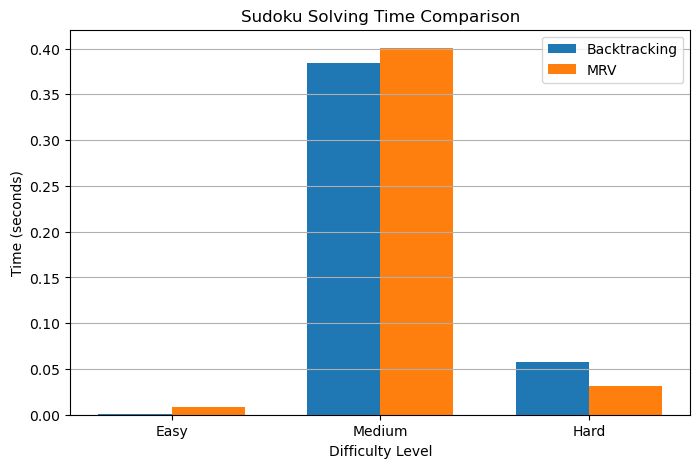

In [13]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Easy", "Medium", "Hard"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, backtracking_times, width, label="Backtracking")
plt.bar(x + width/2, mrv_times, width, label="MRV")

plt.xlabel("Difficulty Level")
plt.ylabel("Time (seconds)")
plt.title("Sudoku Solving Time Comparison")

plt.xticks(x, labels)

plt.legend()
plt.grid(axis='y')

plt.show()

## 4.2 Result Analysis

The results show that the performance of the two algorithms changes depending on the difficulty of the Sudoku puzzle. For the easy puzzle, Backtracking is much faster (about 0.001 s) than MRV (about 0.01 s) because the puzzle has many obvious placements and does not need extra calculations. For the medium puzzle, both algorithms take similar time, but Backtracking is still slightly faster. However, for the hard puzzle, MRV becomes faster (about 0.03 s) than Backtracking (about 0.06 s) because MRV reduces the number of guesses by choosing the cell with the fewest possible values. The bar chart visualizes this comparison: the blue bars represent Backtracking and the orange bars represent MRV, showing that Backtracking performs better for easier puzzles, while MRV performs better for more difficult puzzles.


# 5. Conclusion 
This project demonstrates how different algorithms can be used to solve Sudoku puzzles. Two solving methods were implemented and compared: Backtracking and Minimum Remaining Values (MRV). Backtracking is a simple recursive algorithm that tries possible numbers and backtracks when a conflict occurs. MRV is a heuristic approach that improves the solving process by always selecting the empty cell with the fewest possible values.

The results show that Backtracking performs very well on easy puzzles, where the number of possibilities is small. However, for more difficult puzzles, MRV can be more efficient because it reduces unnecessary guesses and search steps. By measuring and comparing the execution times, the project illustrates how heuristics like MRV can improve problem-solving efficiency in constraint satisfaction problems such as Sudoku.

Overall, the project demonstrates how algorithm design and heuristics influence performance and provides a practical example of applying artificial intelligence techniques to solve logical puzzles.

# 6. Sources
1. https://en.wikipedia.org/wiki/Sudoku_solving_algorithms
2. https://norvig.com/sudoku.html
3. https://www.geeksforgeeks.org/sudoku-backtracking-7/
4. https://www.cs.cmu.edu/~15281-s23/notes/constraints/index.html